<a href="https://colab.research.google.com/github/NoeliaFerrero/Comi-96160-Data-Science-II-Machine-Learning-para-la-Ciencia-de-Datos-Diplomaturas/blob/main/Semana%209%20Analisis%20Uni%20y%20Bivariado/Fundamentos_Estadistica_Analisis_Uni_y_Bivariado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Semana 9 Analisis Uni y Bivariado

🎯 ¿Dónde está? → 📏 ¿Qué tan disperso? → 🔗 ¿Se mueve con otra variable? → 📍 ¿Dónde se ubica? → 📐 ¿Qué forma tiene?

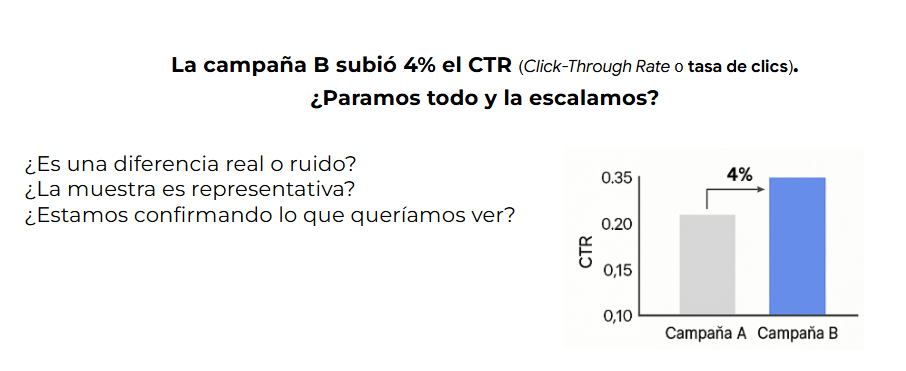

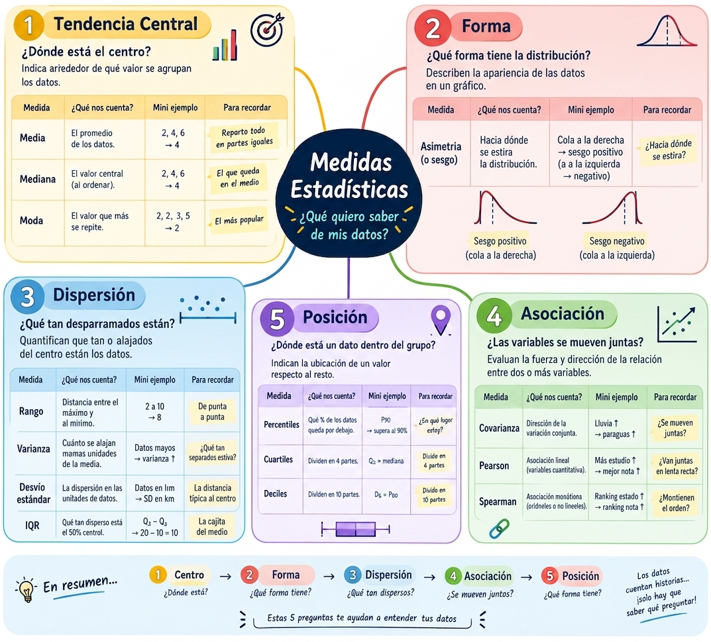

| Grupo                    | 🧠 Pregunta de negocio                                  | ¿Qué miro?                            | Ejemplo fácil                                                         |
| ------------------------ | ------------------------------------------------------- | ------------------------------------- | --------------------------------------------------------------------- |
| 🎯 **Tendencia central** | **¿Cuál es nuestro usuario típico?**                    | Media, mediana, moda                  | ¿Cuál es el gasto típico de nuestros clientes?                        |
| 📐 **Forma**             | **¿Cómo se distribuyen nuestros datos?**                | Asimetría / sesgo                     | ¿La mayoría de los clientes gasta poco y unos pocos gastan muchísimo? |
| 📏 **Dispersión**        | **¿Qué tan diferentes son nuestros usuarios entre sí?** | Rango, varianza, desvío estándar, IQR | ¿Todos gastan parecido o tenemos clientes muy distintos?              |
| 🔗 **Asociación**        | **¿Hay variables que se mueven juntas?**                | Covarianza, Pearson, Spearman         | ¿Cuando aumenta la inversión en publicidad, aumentan las ventas?      |
| 📍 **Posición**          | **¿Dónde está cada usuario/dato dentro del grupo?**     | Percentiles, cuartiles, deciles       | ¿Qué clientes están por debajo del 70% de las ventas (**D7**)?                         |


In [ ]:
# Preparación mínima
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 2)

print("Listos para conocer a nuestros datos..!")


Listos para conocer a nuestros datos.


## Antes de calcular: ¿qué estamos mirando?

- **Población:** universo de observaciones que contiene todas las unidades de observación posibles.
- **Muestra:** conjunto de observaciones de las unidades a las que tenemos acceso.
- **Unidad de observación:** conjunto de variables representadas con datos (básicamente, una variable siempre SE PUEDE MEDIR a través de varias escalas de medición).

Aca aparece una idea clave: la **inferencia estadística** permite inferir el comportamiento de una población a partir de una muestra.

Sin código todavía:

> Si tenemos datos de 500 personas y queremos decir algo sobre todas las personas de una población, ¿qué tenemos: población o muestra?

La respuesta no se busca en Google. Se discute primero. 😉

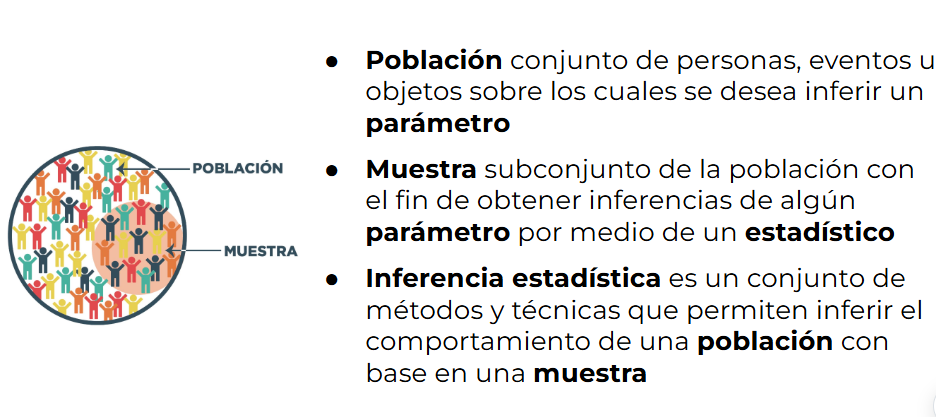

## Variables: no todo número se trata igual

### Variables cuantitativas
Tiene sentido realizar **suma, resta o promedio**.  
Se clasifican en **continuas** y **discretas**.

### Variables cualitativas
Sirven para **categorizar elementos**.  
Se clasifican en **nominales** y **ordinales**.

> La idea importante: el tipo de variable condiciona qué operaciones tiene sentido hacer.

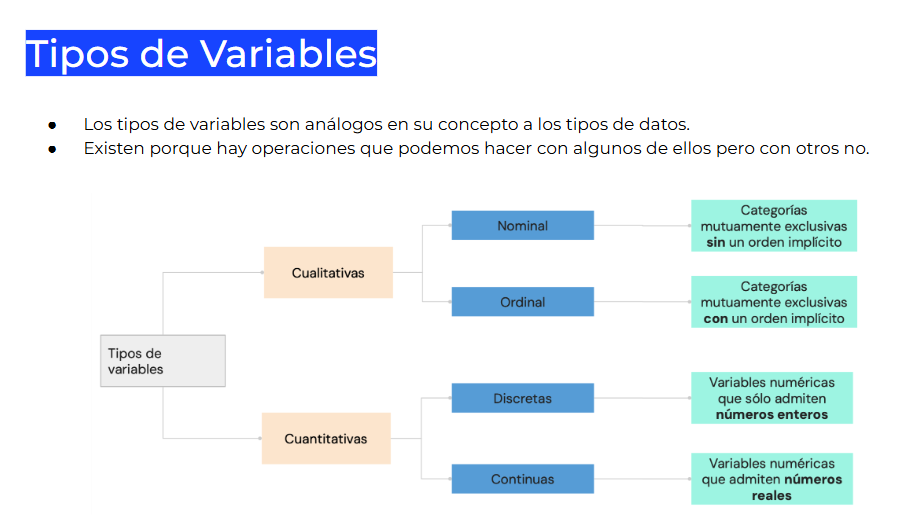

In [ ]:
# Mini actividad: clasifiquemos algunas variables
variables = pd.DataFrame({
    "variable": [
        "edad",
        "cantidad de compras",
        "nivel de satisfacción",
        "color favorito"
    ],
    "tipo_a_discutir": ["?", "?", "?", "?"]
})

variables


,variable,tipo_a_discutir
0,edad,?
1,cantidad de compras,?
2,nivel de satisfacción,?
3,color favorito,?


## 💬 Pregunta rápida

Completen oralmente:

- ¿Cuál es cuantitativa?
- ¿Cuál es cualitativa?
- ¿Cuál tiene orden?
- ¿Cuál no tiene orden?

No hace falta programar nada para responder esto.

## Estadística descriptiva

La estadística descriptiva se encarga de **recolectar, organizar, resumir y presentar** datos de manera informativa.

La pregunta que nos guía ahora es:

> **¿Cómo resumimos miles de datos sin perder completamente la película?**

Ahí aparecen las **medidas de tendencia central**:

- Media
- Mediana
- Moda

# **1. Medidas de Tendencia Central**

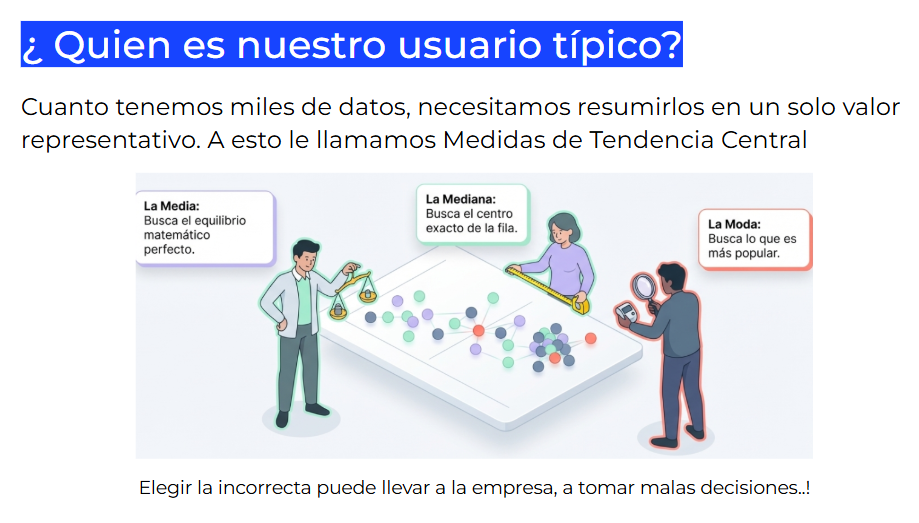

## 1.1 Media

La media aritmética es:

**suma de todos los valores / cantidad de valores**

Vamos a calcularla primero “a mano” con Python, para que se vea qué está haciendo realmente.

In [ ]:
notas = np.array([6, 7, 8, 9, 10])

media = notas.sum() / len(notas)

print("Datos:", notas)
print("Suma:", notas.sum())
print("Cantidad de datos:", len(notas))
print("Media:", media)


Datos: [ 6  7  8  9 10]
Suma: 40
Cantidad de datos: 5
Media: 8.0


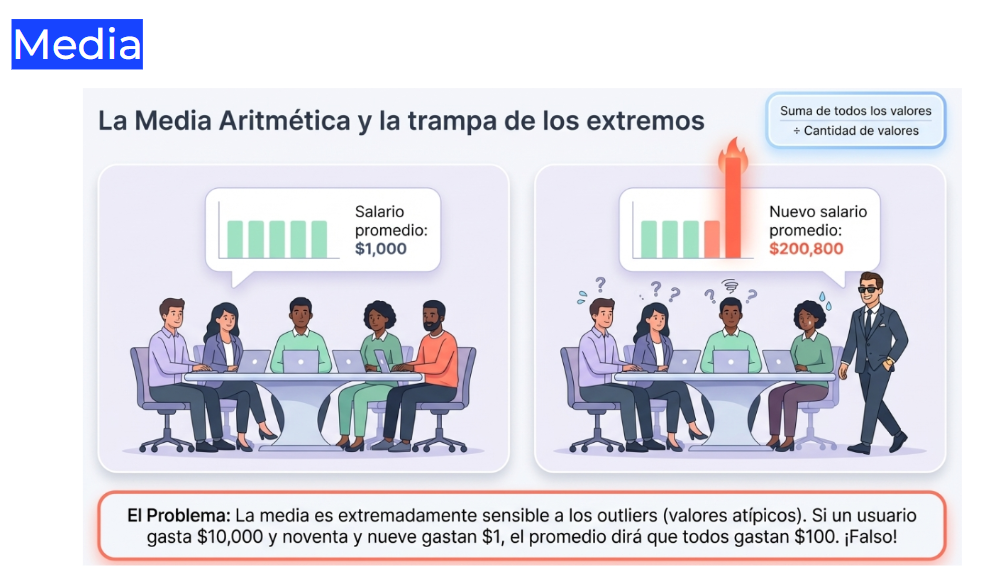

## 1.2 Mediana

La mediana es el valor que separa la mitad superior de la mitad inferior de un conjunto de datos **ordenados**.



### Ejemplo impar

`[1, 2, 3, 5, 7, 8, 9, 10, 15]`

Hay 9 elementos → la posición central es la 5 → **mediana = 7**.

In [ ]:
datos_impar = np.array([1, 2, 3, 5, 7, 8, 9, 10, 15])

print("Mediana:", np.median(datos_impar))


Mediana: 7.0


### Ejemplo par

`[-5, -1, 0, 1, 2, 3, 8, 20]`

Hay 8 elementos → tomamos los dos valores centrales:

**(1 + 2) / 2 = 1.5**

In [ ]:
datos_par = np.array([-5, -1, 0, 1, 2, 3, 8, 20])

print("Mediana:", np.median(datos_par))


Mediana: 1.5


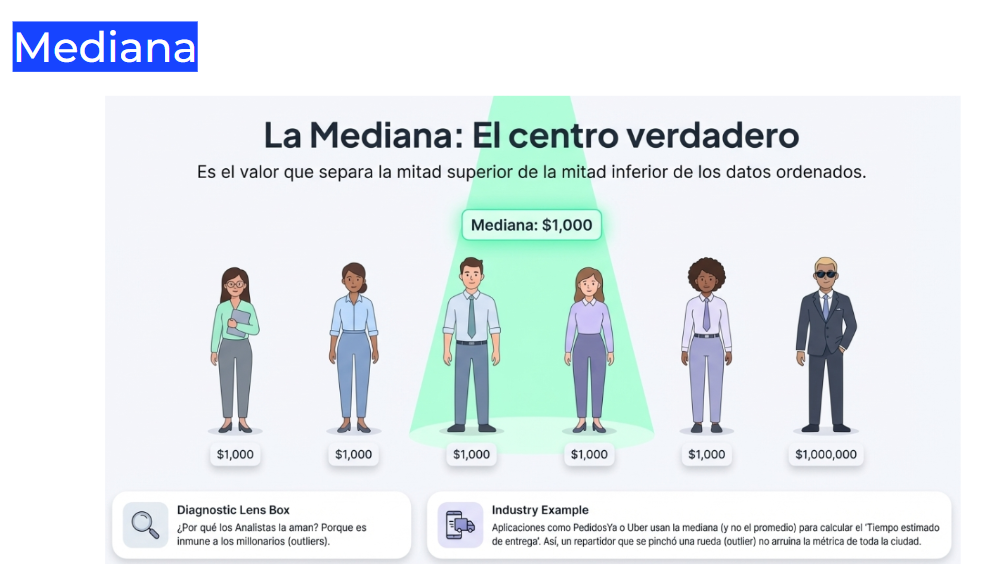

## 1.3 Moda

La moda es el valor que aparece con mayor frecuencia.

Puede ser:

- unimodal
- bimodal
- trimodal
- o no existir si todos los valores son únicos

In [ ]:
datos_moda = [0, 1, 1, 2, 2, 2, 2, 3, 3, 4, 4, 4, 5]

frecuencias = pd.Series(datos_moda).value_counts().sort_index()

print(frecuencias)
print("\nModa:", pd.Series(datos_moda).mode().tolist())


0    1
1    2
2    4
3    2
4    3
5    1
Name: count, dtype: int64

Moda: [2]


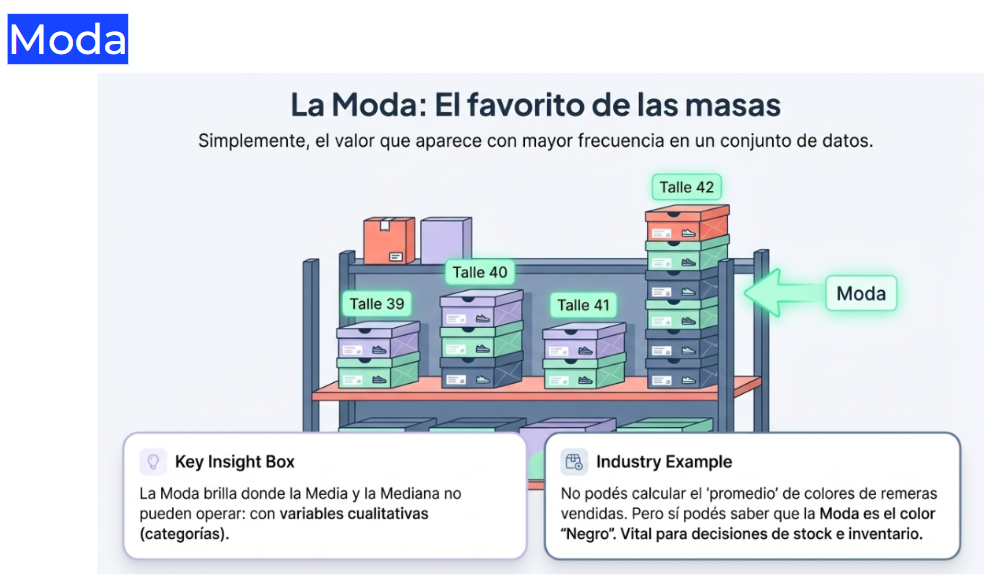

## 🎯 Mini desafío

En el siguiente conjunto, ¿cuál creen que es la moda?

`[10, 13, 13, 20, 20]`

**Ojo:** la moda no necesariamente es única.

In [ ]:
datos_bimodales = [10, 13, 13, 20, 20]

pd.Series(datos_bimodales).mode().tolist()


## Cuando la media engaña 😈

Usemos estos datos de ejemplo:

`[25k, 26k, 27k, 28k, 300k]`

La media es **81.2k**, mientras que la mediana es **27k**.

La pregunta para el grupo:

> Si me preguntan cuál es el salario “típico”, ¿qué medida representa mejor estos datos?

In [ ]:
sueldos = np.array([25_000, 26_000, 27_000, 28_000, 300_000])

print("Media:", sueldos.mean())
print("Mediana:", np.median(sueldos))


Media: 81200.0
Mediana: 27000.0


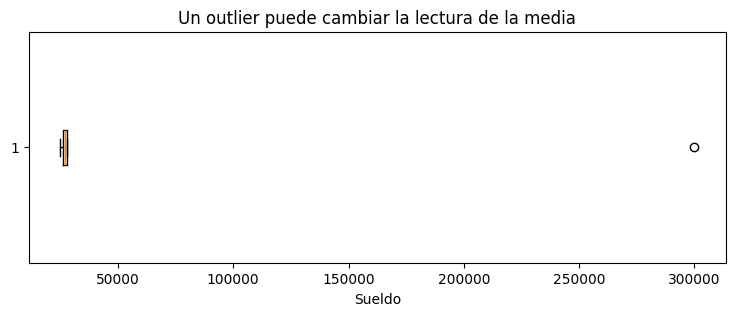

In [ ]:
# Lo vemos
plt.figure(figsize=(9, 3))
plt.boxplot(sueldos, vert=False)
plt.xlabel("Sueldo")
plt.title("Un outlier puede cambiar la lectura de la media")
plt.show()


## 🧠 Conclusión del bloque

En distribuciones sesgadas o con outliers, la media puede distorsionar la interpretación.

**Interpretar = traducir estadística en información útil.**

No alcanza con decir “la media dio X”. Hay que mirar cómo se distribuyen los datos.

# **2. Medidas de Asimetría (Forma)**

La asimetría indica si los datos están sesgados hacia la izquierda o hacia la derecha de la media.

- **Asimetría positiva / sesgo a la derecha:** cola más larga hacia valores altos.
- **Asimetría negativa / sesgo a la izquierda:** cola más larga hacia valores bajos.
- **Simetría:** colas aproximadamente iguales.

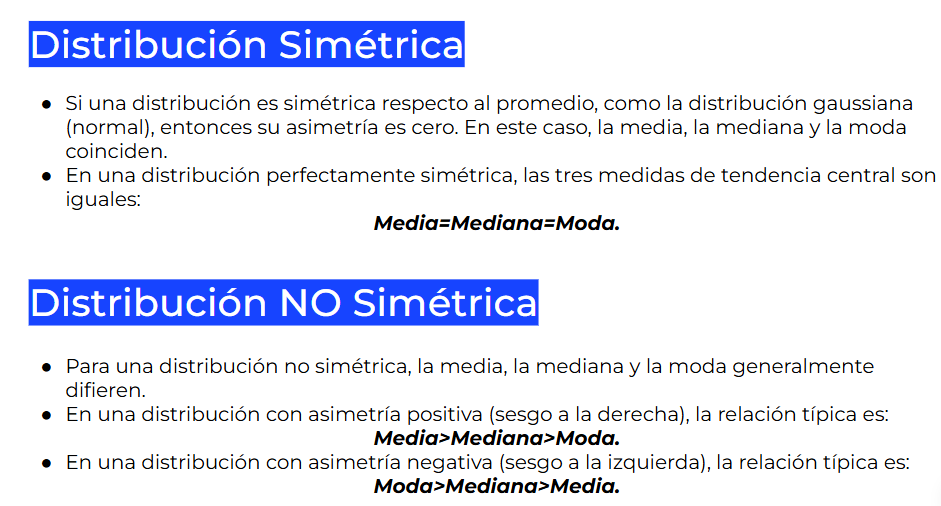

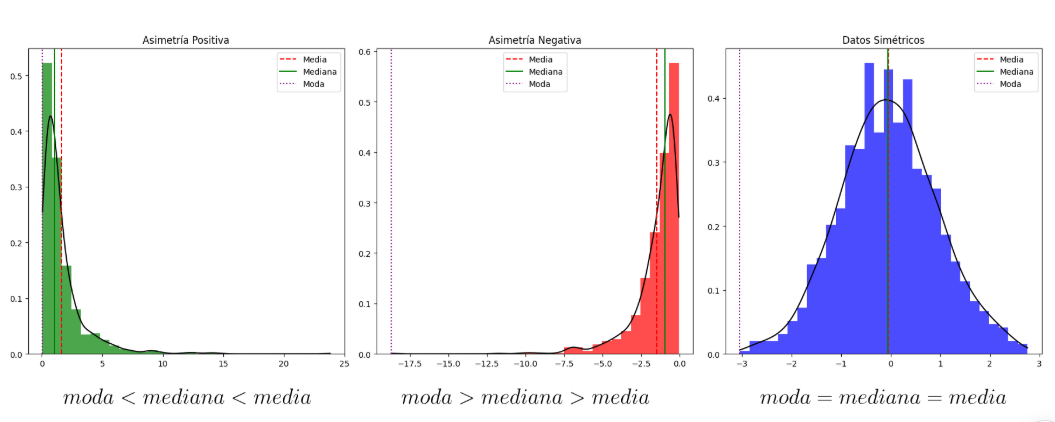

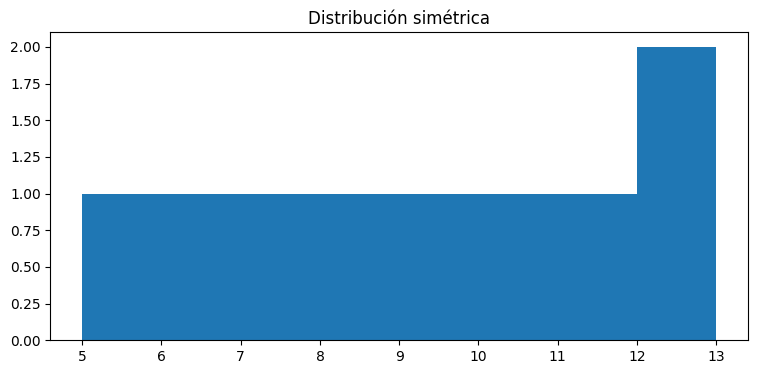

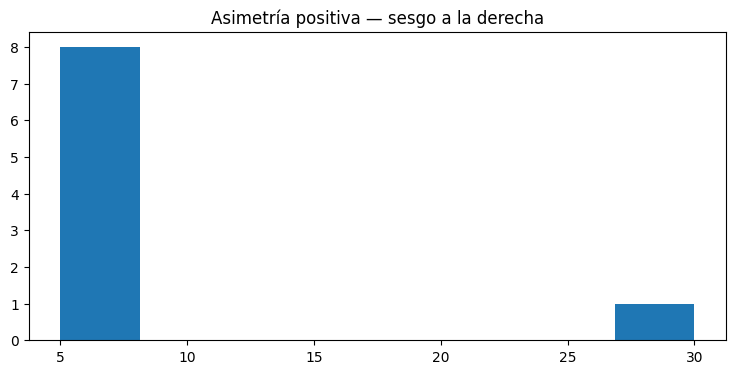

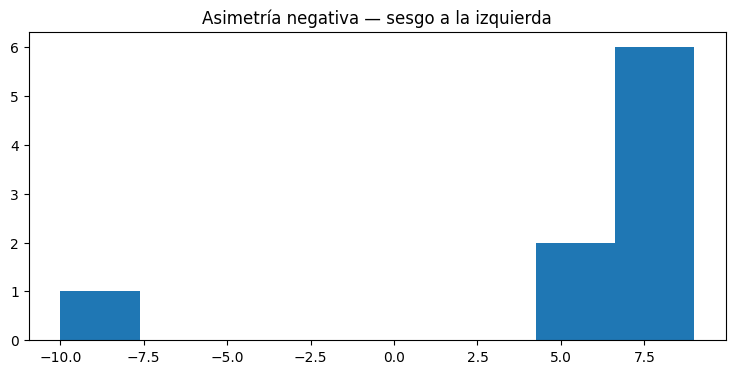

In [ ]:
# Las tres formas de distribución
simetrica = np.array([5, 6, 7, 8, 9, 10, 11, 12, 13])
sesgo_derecha = np.array([5, 6, 6, 7, 7, 7, 8, 8, 30])
sesgo_izquierda = np.array([-10, 5, 6, 7, 7, 8, 8, 8, 9])

plt.figure(figsize=(9, 4))
plt.hist(simetrica, bins=8)
plt.title("Distribución simétrica")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(sesgo_derecha, bins=8)
plt.title("Asimetría positiva — sesgo a la derecha")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(sesgo_izquierda, bins=8)
plt.title("Asimetría negativa — sesgo a la izquierda")
plt.show()


# **3. Medidas de dispersión o variabilidad**

Ahora cambiamos la pregunta.

Ya no preguntamos:

> “¿Dónde está el centro?”

Preguntamos:

> **“¿Qué tan separados están los datos?”**

Vamos a ver:

- Rango
- Varianza
- Desvío estándar

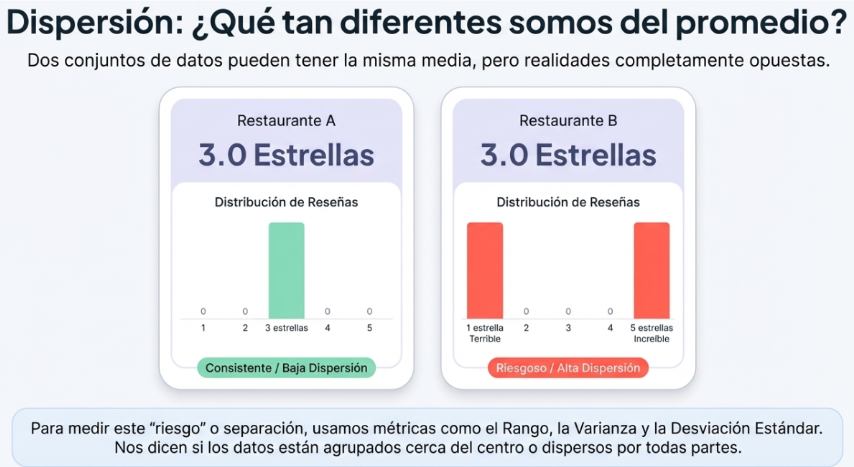

### 3.1 Rango

El rango es:

**máximo − mínimo**

In [ ]:
datos = np.array([6, 7, 8, 9, 10])

rango = datos.max() - datos.min()

print("Máximo:", datos.max())
print("Mínimo:", datos.min())
print("Rango:", rango)


## 3.2 Varianza y desvío estándar

Si tenemos estas notas:

`[6, 7, 8, 9, 10]`

Promedio = 8

Distancias al promedio:

`-2, -1, 0, 1, 2`

Al cuadrado:

`4, 1, 0, 1, 4`

Varianza:

`(4 + 1 + 0 + 1 + 4) / 5 = 2`

Desvío estándar:

`√2 ≈ 1.41`

La varianza es un paso intermedio; el desvío estándar queda en las mismas unidades que los datos originales.

In [ ]:
datos = np.array([6, 7, 8, 9, 10])
media = datos.mean()
distancias = datos - media
cuadrados = distancias ** 2
varianza = cuadrados.mean()
desvio = np.sqrt(varianza)

print("Datos:", datos)
print("Media:", media)
print("Distancias:", distancias)
print("Distancias al cuadrado:", cuadrados)
print("Varianza:", varianza)
print("Desvío estándar:", round(desvio, 2))


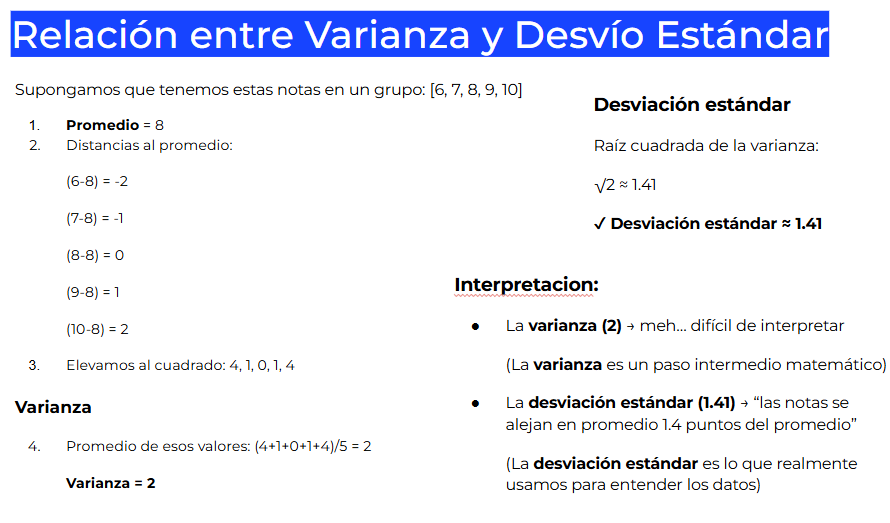

## 💬 Pregunta rápida

Dos grupos pueden tener el mismo promedio.

¿Eso significa necesariamente que sus datos están distribuidos de la misma manera?

👉 Acá aparece el sentido de mirar también la **variabilidad**.

# **4. Medidas de asociación**

Ahora pasamos de **una variable** a **dos variables**.



## 4.1 Covarianza

Mide el grado en que dos variables cambian conjuntamente.

- positiva → tienden a aumentar juntas
- negativa → una tiende a aumentar cuando la otra disminuye

Es una medida de asociación lineal.

In [ ]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 4, 9, 16, 25])

covarianza = np.cov(x, y, ddof=1)[0, 1]

print("Covarianza:", covarianza)


## 4.2 Correlación

La correlación también describe la relación entre dos variables, pero incorpora:

- **dirección**
- **fuerza**

y es independiente de la escala de las variables.

### Pearson
Mide la relación lineal. Sus valores van de **-1 a 1**.

### Spearman
Mide la relación monotónica utilizando **rangos** en lugar de los valores originales.

In [ ]:
x = pd.Series([1, 2, 3, 4, 5])
y = pd.Series([1, 4, 9, 16, 25])

print("Pearson:", x.corr(y, method="pearson"))
print("Spearman:", x.corr(y, method="spearman"))


## ☂️ El caso de los paraguas

Variables:

- X = ventas de paraguas
- Y = cantidad de accidentes de tránsito

Si aumentan las ventas de paraguas y también aumentan los accidentes, podemos observar una asociación positiva.

Pero...

> **¿Comprar paraguas provoca accidentes?**

Hay una tercera variable:

🌧️ **Lluvia**

Más lluvia → más paraguas  
Más lluvia → calles resbalosas → más accidentes

**Las variables se mueven juntas, pero no necesariamente porque una cause a la otra.**

La covarianza detecta patrones; **no explica causas**.

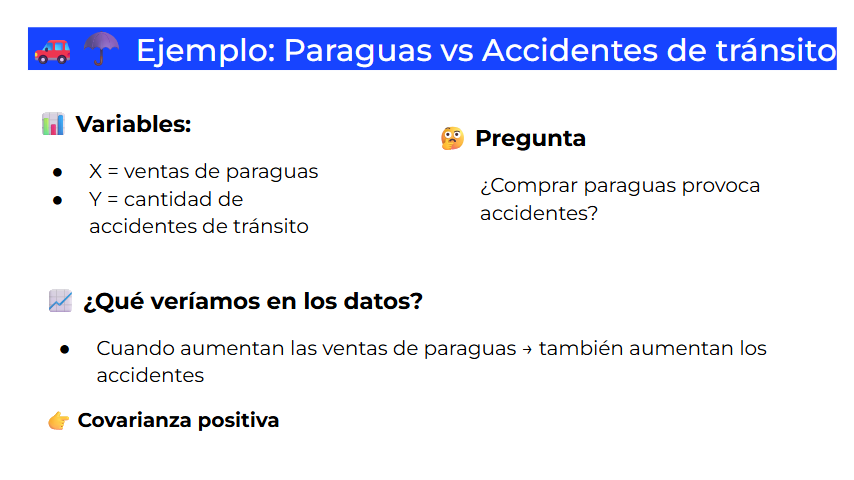

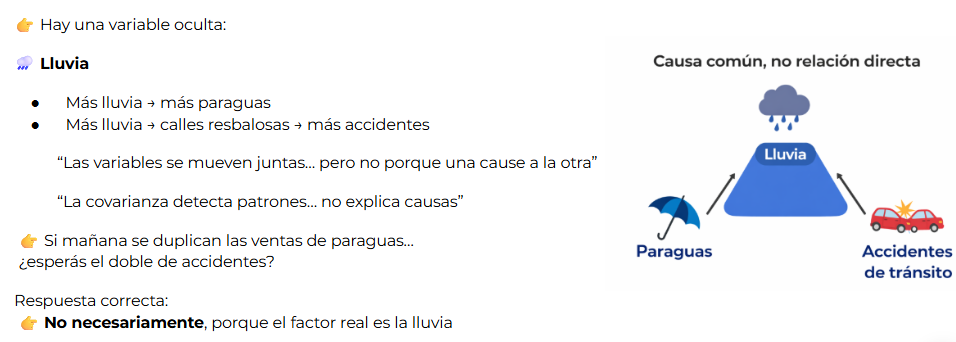

In [ ]:
# Simulamos el ejemplo de manera sencilla
lluvia = np.array([1, 2, 3, 4, 5, 6, 7, 8])
paraguas = np.array([2, 4, 5, 7, 9, 11, 13, 15])
accidentes = np.array([1, 2, 3, 5, 6, 8, 10, 12])

df = pd.DataFrame({
    "lluvia": lluvia,
    "ventas_paraguas": paraguas,
    "accidentes": accidentes
})

df


In [ ]:
print("Correlación paraguas ↔ accidentes:",
      df["ventas_paraguas"].corr(df["accidentes"]))

plt.figure(figsize=(7, 4))
plt.scatter(df["ventas_paraguas"], df["accidentes"])
plt.xlabel("Ventas de paraguas")
plt.ylabel("Accidentes")
plt.title("Asociación: paraguas vs. accidentes")
plt.show()


# **5. Medidas de posición**

Las medidas de posición ayudan a entender **dónde se ubican los datos dentro de una distribución**.

La presentación trabaja:

- Percentiles
- Deciles
- Cuartiles

Se usan con datos numéricos porque necesitamos **ordenarlos y comparar magnitudes**.

También pueden utilizarse con datos ordinales.

No aplican a categorías sin orden, como color favorito, país o nombre.

### Para no perderse con las divisiones

- 4 partes → 3 cortes
- 10 partes → 9 cortes
- 100 partes → 99 cortes

Si dividimos en **N partes**, necesitamos **N − 1 cortes**.

> No contamos las partes. Contamos dónde hacemos los cortes.

## 5.1 Percentiles

Un percentil es un valor debajo del cual se encuentra un determinado porcentaje de observaciones.

Ejemplo:

**P25** → debajo de ese valor se encuentra el 25% de las observaciones.



In [ ]:
datos = np.array([30, 36, 47, 50, 52, 52, 56, 60, 63, 70, 70, 110])

print("P25:", np.percentile(datos, 25))
print("P50:", np.percentile(datos, 50))
print("P75:", np.percentile(datos, 75))


## 5.2 Deciles

Los deciles dividen el conjunto de datos en **diez partes iguales**.

- D1 = P10
- D2 = P20
- ...
- D9 = P90

In [ ]:
for k in range(1, 10):
    print(f"D{k} = P{k*10}: {np.percentile(datos, k*10):.2f}")


## 5.3 Cuartiles

Los cuartiles dividen los datos en **cuatro partes iguales**.

- Q1 = P25
- Q2 = P50 = mediana
- Q3 = P75

La presentación usa para las posiciones:

- Q1 → `(N + 1) / 4`
- Q3 → `3(N + 1) / 4`

In [ ]:
datos = np.array([30, 36, 47, 50, 52, 52, 56, 60, 63, 70, 70, 110])

n = len(datos)

pos_q1 = (n + 1) / 4
pos_q3 = 3 * (n + 1) / 4

print("N =", n)
print("Posición Q1 =", pos_q1)
print("Posición Q3 =", pos_q3)
print("Q1 =", np.percentile(datos, 25))
print("Q2 =", np.percentile(datos, 50))
print("Q3 =", np.percentile(datos, 75))


### 🔎 Para estos datos:

`30 36 47 50 52 52 56 60 63 70 70 110`

Podemos obtener:

- **Q1 = 47.75**
- **Q2 = 54**
- **Q3 = 68.25**

Ahora hagamos el cálculo de posiciones de forma explícita, para que se vea de dónde salen.

In [ ]:
datos = [30, 36, 47, 50, 52, 52, 56, 60, 63, 70, 70, 110]

n = len(datos)
pos_q1 = (n + 1) / 4
pos_q3 = 3 * (n + 1) / 4

print("Datos ordenados:", datos)
print("Posición Q1:", pos_q1)
print("Posición Q3:", pos_q3)

# Interpolación siguiendo el ejemplo de la presentación
q1 = datos[2] + 0.25 * (datos[3] - datos[2])
q2 = (datos[5] + datos[6]) / 2
q3 = datos[8] + 0.75 * (datos[9] - datos[8])

print("\nQ1 =", q1)
print("Q2 =", q2)
print("Q3 =", q3)


## 5.4 Rango intercuartil (RIC / IQR)

El rango intercuartil es la distancia entre Q1 y Q3:

**RIC = Q3 − Q1**

Representa el rango cubierto por la mitad central de los datos.

In [ ]:
q1 = 47.75
q2 = 54
q3 = 68.25

ric = q3 - q1

print("Q1 =", q1)
print("Q2 =", q2)
print("Q3 =", q3)
print("RIC =", ric)


## 5.5 Outliers

Son los valores ú observaciones significativamente alejadas del resto.

Pueden aparecer por:

- errores de medición
- variabilidad natural
- condiciones experimentales

Tipos:
- atípicos leves → más allá de **1.5 × RIC**
- atípicos extremos → más allá de **3 × RIC**

### 🎯 Desafío

Con los datos del ejemplo:

`30 36 47 50 52 52 56 60 63 70 70 110`

¿Hay valores atípicos?  
¿Son leves o extremos?

In [ ]:
datos = np.array([30, 36, 47, 50, 52, 52, 56, 60, 63, 70, 70, 110])

q1 = 47.75
q3 = 68.25
ric = q3 - q1

limite_inferior_1_5 = q1 - 1.5 * ric
limite_superior_1_5 = q3 + 1.5 * ric

limite_inferior_3 = q1 - 3 * ric
limite_superior_3 = q3 + 3 * ric

print("RIC:", ric)
print("Límite inferior 1.5×RIC:", round(limite_inferior_1_5, 2))
print("Límite superior 1.5×RIC:", round(limite_superior_1_5, 2))
print("Límite inferior 3×RIC:", round(limite_inferior_3, 2))
print("Límite superior 3×RIC:", round(limite_superior_3, 2))

for x in datos:
    if x < limite_inferior_3 or x > limite_superior_3:
        categoria = "extremo"
    elif x < limite_inferior_1_5 or x > limite_superior_1_5:
        categoria = "leve"
    else:
        categoria = "normal"
    print(f"{x}: {categoria}")


## 5.6 Boxplot 📦

El boxplot resume la distribución a través de:

- cuartiles
- mediana
- valores atípicos


📦 **Caja** → donde está la mayoría de los datos  
➖ **Línea central** → mediana  
📏 **Bigotes** → hasta dónde llegan los valores considerados normales  
⚫ **Puntos afuera** → valores raros / outliers

In [ ]:
datos = np.array([30, 36, 47, 50, 52, 52, 56, 60, 63, 70, 70, 110])

plt.figure(figsize=(10, 3))
plt.boxplot(datos, vert=False)
plt.xlabel("Valor")
plt.title("Boxplot")
plt.show()


### 👀 Ahora no calculamos nada

Miremos solamente el gráfico y respondamos:

1. ¿Dónde está la mediana?
2. ¿Dónde está la caja?
3. ¿Qué representa el tamaño de la caja?
4. ¿Qué observación aparece alejada?
5. ¿Qué nos dice el gráfico sobre la distribución?

**La ventaja del boxplot es que permite pasar de una lista de números a una lectura visual.**

# Sesgos cognitivos en el análisis

## Sesgo de confirmación
Buscar y priorizar evidencia que valida la hipótesis propia.

**En DS:** elegir cortes y métricas “que dan bien”.

**Mitigación:** pre-registrar métricas, doble chequeo por pares, reporte de resultados negativos.

---

## Sesgo de supervivencia
Analizar solo a los “que llegaron”.

**Ejemplo:** mirar solo clientes activos para estimar satisfacción.

**Mitigación:** incluir abandonos, muestreo correcto, cohortes.

---

## Sesgo de selección / muestreo
Muestra no representativa: voluntarios, horarios, canales.

**Señal de alerta:** variación por región/segmento no contemplada.

**Mitigación:** aleatorización, estratificación, pesos.

## Otros sesgos frecuentes

- **Anclaje:** la primera cifra condiciona la lectura.
- **Hindsight / retrospectivo:** “era obvio”, sobre-ajuste narrativo.
- **Disponibilidad:** casos memorables pesan más que la evidencia.
- **Publicación / p-hacking:** múltiples pruebas sin corrección.

### 🎯 Actividad rápida: “¿Qué sesgo aparece?”

Lean cada situación y nombren el sesgo:

1. “Analisamos a quienes siguen usando el producto y la satisfacción es altísima.”
2. “La primera cifra que me mostraron fue 70%, así que todo lo demás lo comparo contra 70.”
3. “Yo sabía que esto iba a pasar desde el principio.”
4. “Probé varios cortes hasta encontrar uno donde el resultado quedaba alineado con el esperado.”

In [ ]:
situaciones = pd.DataFrame({
    "situacion": [
        "Miré únicamente a quienes siguen usando el producto y la satisfacción es altísima.",
        "La primera cifra que me mostraron fue 90%, así que todo lo demás lo comparo contra 90.",
        "Yo sabía que esto iba a pasar desde el principio.",
        "Probé varios cortes hasta encontrar uno donde el resultado quedaba lindo."
    ],
    "sesgo": ["?", "?", "?", "?"]
})

situaciones


# Resumen: De los números a la historia

> **Las estadisticas no solo describen datos, sino que ayudan a entender patrones y comportamientos.**

Por ejemplo, la mediana salarial puede ser más representativa que el promedio en contextos con mucha desigualdad.

### 🎯 Cierre de la clase

Volvamos a la pregunta inicial:

> “La campaña B subió 4% el CTR. ¿Paramos todo y la escalamos?”

Ahora tenemos varias preguntas para hacer antes de tomar una decisión:

- ¿Es una diferencia real o ruido?
- ¿La muestra es representativa?
- ¿Qué medida estamos usando?
- ¿Hay valores atípicos?
- ¿Cómo se distribuyen los datos?
- ¿Estamos viendo asociación o interpretándola como causalidad?
- ¿Estamos confirmando lo que queríamos ver?
- ¿Hay algún sesgo en el análisis?

### 🧠 Idea final

**Interpretar datos no es solamente calcular. Es entender qué estamos viendo antes de convertirlo en una decisión.**

## 📝 Mini actividad final — “Traducilo a lenguaje de decisión”

Elegí **uno** de los conceptos abordados en la clase:

- media vs. mediana con salarios
- paraguas vs. accidentes
- clientes activos y sesgo de supervivencia
- muestra no representativa
- outlier del boxplot

Y explicalo en **2 o 3 frases**, como si se la contaras a alguien que no quiere una clase de estadística, sino entender **qué significa el dato**.

Ese es el puente entre:

**números → interpretación → historia → decisión**.